# 04 — Pipeline + GridSearchCV: dữ liệu có cân bằng không, estimator là gì, chọn siêu tham số thế nào

**Đồ án:** *Bẻ gãy bẫy SLA trong thương mại điện tử* · Python for Data Science · PGS.TS Nguyễn Mạnh Hùng

Notebook 03 xây thang mô hình M0–M8 và tune bằng random search tự viết trong `BaseModel.tune`. Notebook này
làm lại bước chọn mô hình theo **cách chuẩn của scikit-learn** và trả lời bốn câu hỏi:

| # | Câu hỏi | Mục |
|---|---|---|
| 1 | Dữ liệu có **cân bằng** không? Nếu không thì xử lý thế nào? | §1 |
| 2 | **Estimator** là gì, nằm ở đâu trong pipeline? | §2 |
| 3 | Dùng **GridSearchCV với Pipeline** (tiền xử lý + estimator) thế nào, điều khiển siêu tham số bằng `__` ra sao? | §3 |
| 4 | **Vì sao chọn** giá trị siêu tham số đó? Có nên **train nhiều lần** thay vì đo một lần? | §4–§6 |

Mọi lựa chọn vẫn quyết định bằng **CV theo thời gian trên tập train ≤2023** (train ≤2021→val 2022, train ≤2022→val 2023).
Tập test 2024–2026 chỉ được mở ở §5, sau khi đã chọn xong.

Code: `src/models/grid_search.py` (có test: `tests/test_grid_search.py`) · chạy lại toàn bộ bằng một lệnh:
`python -m src.models.run_grid_search` (~15 phút, ghi `reports/models/grid_search_*.csv`).

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Thư mục dự án:", ROOT)

Thư mục dự án: /Users/dominhhien/Documents/HCMUTE_HK1_2025/KHDL/datascience_hcmute


In [2]:
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn import set_config
from sklearn.model_selection import ParameterGrid

from src.features.build import TARGET, WEIGHT, temporal_split
from src.models import plots
from src.models.experiments import ARTIFACT_DIR, load_frame
from src.models.grid_search import (CV, best_params_by_family, class_balance_table, make_pipeline,
                                    param_grid, population_ratio, results_table, run_grid_search,
                                    seed_stability, validation_slices)
from src.models.run_grid_search import FAMILIES, balance_sets, evaluate_on_test

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)
plots.apply_theme()
set_config(display="diagram")   # pipeline hiển thị dạng sơ đồ

USE_CACHE = False  # True: đọc kết quả đã lưu ở reports/models/ (vài giây). False: chạy lại GridSearchCV (~15 phút)
print("scikit-learn", sklearn.__version__)

scikit-learn 1.5.1


In [3]:
frame = load_frame()
train, test = temporal_split(frame)
y_train = train[TARGET].to_numpy()
print(f"train ≤2023: {len(train):,} review · test 2024–2026: {len(test):,} review")

train ≤2023: 157,173 review · test 2024–2026: 41,182 review


## 1. Dữ liệu có cân bằng không?

Biến mục tiêu: `is_low_rating = 1` nếu review ≤3★ (lớp dương), `0` nếu 4–5★. Mỗi tập được đếm theo **hai cách**:

* **tỉ lệ thô** — đếm dòng trong mẫu đã cào;
* **tỉ lệ quần thể** — nhân trọng số khảo sát `w = N_h / n_h`. Đây mới là tỉ lệ thật trên Tiki, vì scraper **cố ý**
  cào vét cạn review 1–3★ và chỉ lấy mẫu review 5★ (notebook 02 · lấy mẫu phân tầng).

,n,n_dương,tỉ_lệ_thô,tỉ_lệ_quần_thể,âm_trên_dương_quần_thể
train ≤2023,"157,173","15,132",9.63%,4.45%,21.5 : 1
test 2024–2026,"41,182","1,465",3.56%,1.68%,58.6 : 1
CV val 2022,"54,829","3,614",6.59%,2.83%,34.3 : 1
CV val 2023,"26,591","1,204",4.53%,1.95%,50.3 : 1


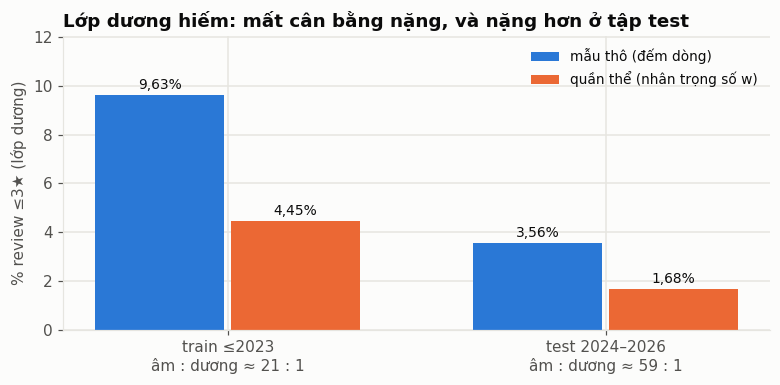

In [4]:
balance = class_balance_table(balance_sets(train, test))
display(balance.style.format({"n": "{:,}", "n_dương": "{:,}", "tỉ_lệ_thô": "{:.2%}",
                              "tỉ_lệ_quần_thể": "{:.2%}", "âm_trên_dương_quần_thể": "{:.1f} : 1"}))
plots.plot_class_balance(balance.loc[["train ≤2023", "test 2024–2026"]]);

In [5]:
# Bẫy accuracy: mô hình "luôn đoán 4–5★" — không học gì — đạt accuracy bao nhiêu trên test?
prev_test = np.average(test[TARGET], weights=test[WEIGHT])
print(f"Accuracy của mô hình luôn đoán 'không phải review xấu' trên test: {1 - prev_test:.2%}")
print(f"PR-AUC của một mô hình đoán ngẫu nhiên = tỉ lệ dương = {prev_test:.4f}  → mốc so sánh của §5")

Accuracy của mô hình luôn đoán 'không phải review xấu' trên test: 98.32%
PR-AUC của một mô hình đoán ngẫu nhiên = tỉ lệ dương = 0.0168  → mốc so sánh của §5


**Trả lời §1 — dữ liệu KHÔNG cân bằng, và càng về sau càng lệch.**

* Lớp dương chỉ **4,45%** quần thể train (âm : dương ≈ 21 : 1) và **1,68%** quần thể test (≈ 59 : 1). Tỉ lệ thô (9,63%)
  gấp đôi tỉ lệ thật vì thiết kế lấy mẫu — báo cáo tỉ lệ thô là sai.
* Mất cân bằng tăng dần theo năm (21 → 34 → 50 → 59 : 1): review xấu ngày càng hiếm. Đây là **trôi dạt prior** — lý do
  xác suất phải được hiệu chỉnh trên năm gần nhất (notebook 03 §10).
* Hệ quả: mô hình "luôn đoán không" đạt accuracy **98,3%** mà không học gì → **accuracy bị loại**. Thước đo là PR-AUC,
  mốc ngẫu nhiên = tỉ lệ dương (0,0168), và lift = PR-AUC ÷ mốc đó.

**Xử lý thế nào — ba lựa chọn, chọn cái thứ ba:**

| Cách | Vì sao (không) dùng |
|---|---|
| Undersample lớp âm | Vứt bỏ ~95% review 4–5★ đã cào; và mẫu đã được phân tầng theo sao có chủ đích |
| SMOTE / oversample | Sinh review "ảo" nội suy giữa các review thật → sai trọng số khảo sát `w = N_h/n_h`; nội suy biến phân loại vô nghĩa |
| **Trọng số lớp** (`class_weight`) | Không thêm/bớt dòng, giữ nguyên trọng số khảo sát, nhân thêm hệ số cho lớp hiếm. Ba mức (`None`, `"balanced"`, `{1: 21,5}`) là **siêu tham số** để GridSearchCV chọn ở §3 |

## 2. Estimator và Pipeline

Trong scikit-learn, **estimator** là bất kỳ đối tượng nào có `fit()` — học tham số từ dữ liệu. Bộ phân loại
(`LogisticRegression`, `RandomForestClassifier`, `HistGradientBoostingClassifier`) là estimator có thêm
`predict_proba()`. Bộ tiền xử lý (`SimpleImputer`, `StandardScaler`, `OneHotEncoder`) cũng là estimator, loại
*transformer* (`fit` + `transform`).

`Pipeline` xâu chúng thành **một estimator duy nhất**: `fit` của pipeline = `fit_transform` từng bước tiền xử lý rồi
`fit` bước cuối. Nhờ vậy khi GridSearchCV clone và fit pipeline trong từng fold, **trung vị, trung bình, độ lệch chuẩn
chỉ được học từ phần train của fold** — không rò rỉ từ phần kiểm định.

In [6]:
pipe = make_pipeline()
pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['lead_days',
                                                   'delivered_hour',
                                                   'delivered_weekend',
                                                   'purchase_month',
                                                   'purchase_weekday',
                                                   'purchase_hour',
                                                   'is_tiki_trading',
                                                   'log_price', 'discount_rate',
                                                   'prod_hist_n',
                                                   'prod_hist_rate',
                                                   'seller_hist_n',
                                                   'seller_hist_rate',
                                                   'cust_tenure_days',
                                                   'cust_hist_n',
                                                   'cust_hist_rate']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['category'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [7]:
# Mọi siêu tham số của mọi bước đều gọi được bằng  <tên bước>__<tham số>  (lồng bao nhiêu tầng cũng được)
keys = pd.Series(sorted(pipe.get_params()))
display(keys[keys.str.match(r"^(model__(C|class_weight|max_iter|penalty)|prep__num__impute__(strategy|add_indicator)"
                            r"|prep__num__scale__with_(mean|std)|prep__cat__handle_unknown)$")].to_frame("khoá hợp lệ"))

demo = make_pipeline().set_params(model__C=0.01, prep__num__impute__strategy="mean")
print("model__C                      →", demo.named_steps["model"].C)
print("prep__num__impute__strategy   →", demo.named_steps["prep"].transformers[0][1].named_steps["impute"].strategy)

,khoá hợp lệ
2,model__C
3,model__class_weight
8,model__max_iter
11,model__penalty
23,prep__cat__handle_unknown
31,prep__num__impute__add_indicator
36,prep__num__impute__strategy
40,prep__num__scale__with_mean
41,prep__num__scale__with_std


model__C                      → 0.01
prep__num__impute__strategy   → mean


**Estimator của từng mô hình trong thang M0–M8 (notebook 03):**

| Mô hình | Estimator (bước `model`) | Tiền xử lý (bước `prep`) |
|---|---|---|
| M0 · tỉ lệ chung | `PriorBaseline` (tự viết — đoán một hằng số) | không |
| M1a, M1b, M2 · logistic | `LogisticRegression` (lbfgs, phạt L2) | điền thiếu + chuẩn hoá + one-hot (M1b: B-spline) |
| M3 · random forest | `RandomForestClassifier` | điền thiếu |
| M4, M5 · GBM | `HistGradientBoostingClassifier` | không — tự xử lý NaN và biến phân loại |
| M6 · ensemble | `EnsembleModel` — trung bình xác suất M5 và M2 | của từng thành viên |
| M7 · CHỐT | `CalibratedModel(M6)` — Platt: `LogisticRegression` trên logit, học trên năm 2023 | — |

Ở notebook này cả ba họ dùng **chung một bước `prep`** để so sánh công bằng: chỉ estimator thay đổi.

## 3. GridSearchCV trên Pipeline — điều khiển siêu tham số bằng `__`

Lưới tìm kiếm là **danh sách dict**, mỗi dict một họ estimator. Khoá `"model"` thay **cả estimator** — chính estimator
cũng là một siêu tham số. Các khoá còn lại điều khiển từng bước bằng `__`:

* `model__C`, `model__min_samples_leaf`, `model__learning_rate`… → tham số của estimator;
* `prep__num__impute__strategy` → tham số của bước tiền xử lý (`prep` → nhánh `num` → bước `impute`);
* `model__class_weight` → cách xử lý mất cân bằng (§1), để CV chọn chứ không chọn tay.

Ba thành phần còn lại của GridSearchCV:

| Tham số | Giá trị | Vì sao |
|---|---|---|
| `cv` | `YearForwardSplit((2022, 2023))` | chia theo năm; KFold xáo trộn cho điểm ảo ×2,3 (notebook 03 §5) |
| `scoring` | PR-AUC **có trọng số khảo sát** | lớp dương hiếm → accuracy vô nghĩa (§1); trọng số → điểm của quần thể |
| `fit(..., model__sample_weight=w)` | trọng số khảo sát chuẩn hoá về trung bình 1 | `__` cũng dùng cho tham số của `fit`: trọng số đi thẳng tới bước `model`, GridSearchCV tự cắt theo fold |

In [8]:
grid = param_grid(round(population_ratio(train), 1))
rows = []
for g in grid:
    fam = type(g["model"][0]).__name__
    for k, v in g.items():
        if k != "model":
            rows.append({"estimator": fam, "khoá": k, "giá trị thử": v, "số giá trị": len(v)})
display(pd.DataFrame(rows))
n_cfg = len(ParameterGrid(grid))
print(f"Tổng: {n_cfg} cấu hình × {CV.get_n_splits()} fold = {n_cfg * CV.get_n_splits()} lần fit")

,estimator,khoá,giá trị thử,số giá trị
0,LogisticRegression,model__C,"[1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0]",7
1,LogisticRegression,model__class_weight,"[None, balanced, {0: 1.0, 1: 21.5}]",3
2,LogisticRegression,prep__num__impute__strategy,"[median, mean]",2
3,RandomForestClassifier,model__min_samples_leaf,"[50, 200, 800, 2000]",4
4,RandomForestClassifier,model__max_features,"[sqrt, 0.5]",2
5,RandomForestClassifier,model__class_weight,"[None, balanced_subsample, {0: 1.0, 1: 21.5}]",3
6,HistGradientBoostingClassifier,model__learning_rate,"[0.03, 0.1]",2
7,HistGradientBoostingClassifier,model__max_leaf_nodes,"[4, 8, 31]",3
8,HistGradientBoostingClassifier,model__min_samples_leaf,"[20, 100, 400]",3
9,HistGradientBoostingClassifier,model__class_weight,"[None, balanced, {0: 1.0, 1: 21.5}]",3


Tổng: 120 cấu hình × 2 fold = 240 lần fit


In [9]:
cached = ARTIFACT_DIR / "grid_search_cv.csv"
if USE_CACHE and cached.exists():
    table = pd.read_csv(cached, keep_default_na=False, na_values=[""])
    search = None
else:
    started = time.perf_counter()
    search = run_grid_search(train, verbose=1)      # GridSearchCV(pipe, grid, cv=CV, scoring=..., refit=True)
    print(f"xong sau {(time.perf_counter() - started) / 60:.1f} phút")
    table = results_table(search)
    print("best_params_ =", {k: (type(v).__name__ if k == "model" else v) for k, v in search.best_params_.items()})
    print(f"best_score_  = {search.best_score_:.4f}  (PR-AUC CV — lạc quan: max của {len(table)} ước lượng nhiễu)")
    if cached.exists():   # tái lập: so với kết quả `run_grid_search` đã lưu
        saved = pd.read_csv(cached, keep_default_na=False, na_values=[""])
        same = np.allclose(saved["mean_test_score"].to_numpy(), table["mean_test_score"].to_numpy())
        print("✔ khớp từng cấu hình với reports/models/grid_search_cv.csv" if same else "✘ KHÁC file đã lưu")

Fitting 2 folds for each of 120 candidates, totalling 240 fits


xong sau 15.3 phút
best_params_ = {'model': 'HistGradientBoostingClassifier', 'model__class_weight': 'balanced', 'model__learning_rate': 0.03, 'model__max_leaf_nodes': 4, 'model__min_samples_leaf': 400}
best_score_  = 0.0582  (PR-AUC CV — lạc quan: max của 120 ước lượng nhiễu)
✔ khớp từng cấu hình với reports/models/grid_search_cv.csv


In [10]:
# 5 cấu hình tốt nhất của từng họ estimator (cột split0 = val 2022, split1 = val 2023)
for fam in FAMILIES:
    sub = table[table["họ"] == fam].dropna(axis=1, how="all").drop(columns=["họ"]).head(5)
    display(sub.style.set_caption(fam).format(precision=4))

,rank,model__C,model__class_weight,prep__num__impute__strategy,mean_test_score,std_test_score,split0_test_score,split1_test_score,mean_train_score,mean_fit_time,rank_trong_họ
27,28,0.0001,1:21.5,mean,0.0569,0.0062,0.0631,0.0506,0.1457,0.1375,1
28,29,0.0001,1:21.5,median,0.0567,0.0061,0.0629,0.0506,0.1457,0.3020,2
31,32,0.0010,None,mean,0.0566,0.0061,0.0627,0.0506,0.1466,0.1401,3
32,33,0.0010,None,median,0.0566,0.0061,0.0626,0.0505,0.1466,0.2556,4
33,34,0.0001,balanced,mean,0.0566,0.0060,0.0626,0.0506,0.1450,0.1718,5


,rank,model__class_weight,model__max_features,model__min_samples_leaf,mean_test_score,std_test_score,split0_test_score,split1_test_score,mean_train_score,mean_fit_time,rank_trong_họ
22,23,1:21.5,sqrt,200.0000,0.0570,0.0082,0.0652,0.0488,0.1820,3.5482,1
29,30,balanced_subsample,sqrt,200.0000,0.0567,0.0080,0.0647,0.0487,0.1817,4.4357,2
37,38,None,sqrt,200.0000,0.0565,0.0075,0.0640,0.0489,0.1799,3.6161,3
51,52,balanced_subsample,0.5000,200.0000,0.0558,0.0073,0.0631,0.0485,0.1881,10.0918,4
52,53,1:21.5,0.5000,800.0000,0.0558,0.0081,0.0639,0.0476,0.1581,6.2872,5


,rank,model__class_weight,model__min_samples_leaf,model__learning_rate,model__max_leaf_nodes,mean_test_score,std_test_score,split0_test_score,split1_test_score,mean_train_score,mean_fit_time,rank_trong_họ
0,1,balanced,400.0000,0.0300,4.0000,0.0582,0.0074,0.0657,0.0508,0.1701,8.0795,1
1,2,1:21.5,400.0000,0.0300,4.0000,0.0580,0.0071,0.0651,0.0509,0.1661,6.7458,2
2,3,balanced,400.0000,0.1000,4.0000,0.0579,0.0075,0.0654,0.0504,0.1711,2.9726,3
3,4,1:21.5,400.0000,0.1000,4.0000,0.0579,0.0072,0.0651,0.0507,0.1661,2.0992,4
4,5,balanced,20.0000,0.0300,8.0000,0.0579,0.0076,0.0655,0.0503,0.1793,5.5993,5


**Đọc kết quả §3.**

* `best_params_` là **HistGradientBoostingClassifier** (4 lá, `min_samples_leaf=400`, `learning_rate=0,03`,
  `class_weight="balanced"`), `best_score_` = 0,0582. Đó là điểm **lạc quan** — max của 120 ước lượng nhiễu trên chính
  các fold dùng để chọn.
* Cấu hình tốt nhất của ba họ cách nhau chỉ ~0,0013 PR-AUC, trong khi cùng một cấu hình chênh ~0,015 giữa val 2022 và
  val 2023. Trên CV, ba họ **gần như ngang nhau**.
* Logistic tốt nhất (`C=1e-4`, `class_weight={1: 21,5}`) đạt 0,0569 — gần như trùng logistic tune bằng random search ở
  notebook 03 (0,0566), dù cách tìm và cách chuẩn hoá trọng số khác nhau. Hai phương pháp tìm độc lập cho cùng một kết luận.
* **Lượt chạy đầu** (lưới hẹp hơn) có ba tham số thắng ở **mép lưới**: `C=1e-4` (nhỏ nhất), RF `min_samples_leaf=200`
  (lớn nhất), GBM `max_leaf_nodes=8` (nhỏ nhất). Thắng ở mép = tối ưu có thể nằm ngoài vùng đã thử → lưới được mở rộng
  về phía đó (`C` tới 1e-6, RF tới 2000, GBM xuống 4 lá) và chạy lại. Kết quả ở trên là lượt hai.

## 4. Vì sao chọn giá trị siêu tham số này?

**Validation curve đọc thẳng từ lưới**: giữ mọi tham số khác ở cấu hình thắng của họ, chỉ đổi **một** tham số và
xem PR-AUC CV thay đổi ra sao. Các ô cùng hàng chung trục y, nên ô dốc = tham số quyết định, ô phẳng = tham số ít
ảnh hưởng.

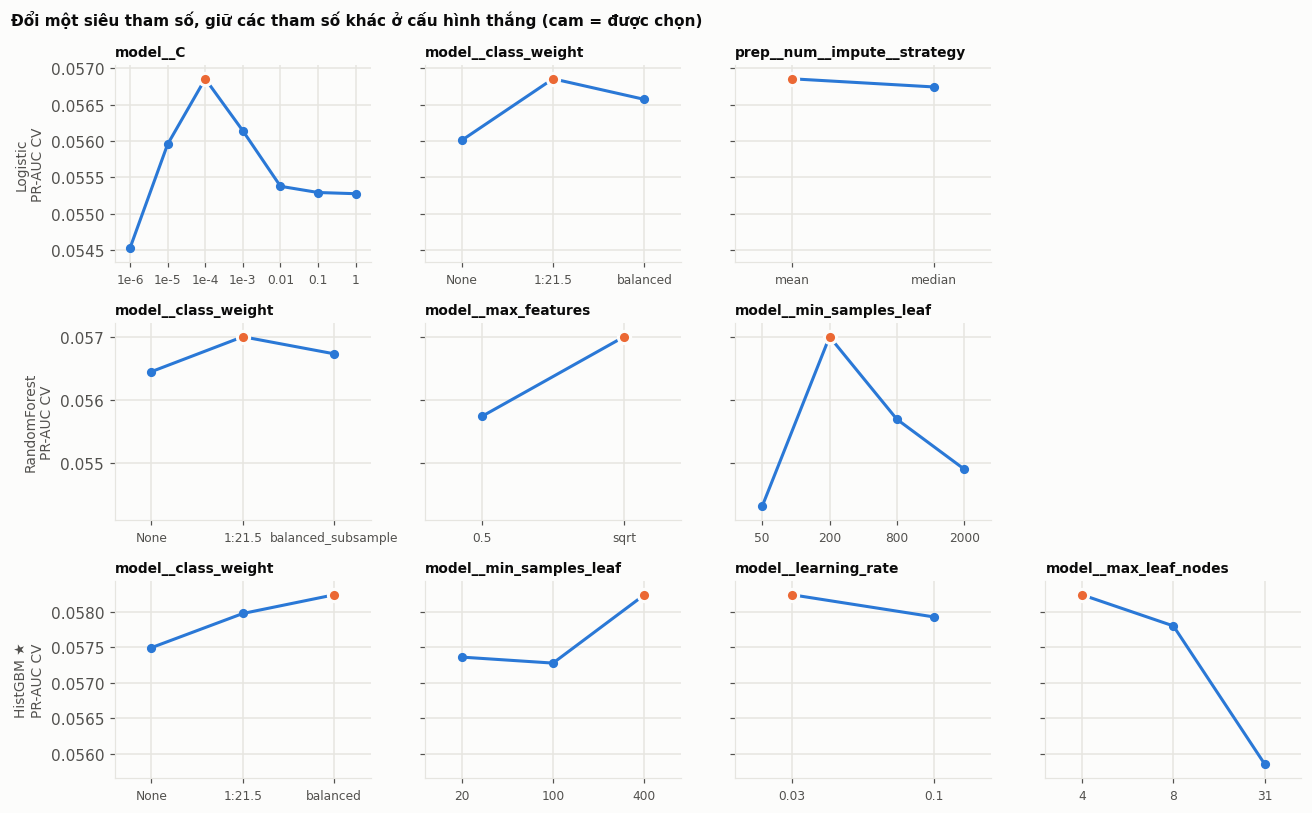

In [11]:
slices = {fam: validation_slices(table, fam) for fam in FAMILIES}
plots.plot_validation_curves(slices, best_overall=table.iloc[0]["họ"]);

In [12]:
# Bảng số của hình trên: giá trị được chọn, và CV dao động bao nhiêu khi đổi riêng tham số đó
rows = []
for fam, fam_slices in slices.items():
    for prm, d in fam_slices.items():
        k = d["mean_test_score"].idxmax()
        rows.append({"họ": fam, "siêu tham số": prm, "chọn": d.loc[k, prm],
                     "PR-AUC CV tại giá trị chọn": d.loc[k, "mean_test_score"],
                     "tệ nhất khi đổi tham số này": d["mean_test_score"].min(),
                     "độ nhạy (max − min)": d["mean_test_score"].max() - d["mean_test_score"].min()})
sens = pd.DataFrame(rows)
sens

,họ,siêu tham số,chọn,PR-AUC CV tại giá trị chọn,tệ nhất khi đổi tham số này,độ nhạy (max − min)
0,Logistic,model__C,0.0001,0.0569,0.0545,0.0023
1,Logistic,model__class_weight,1:21.5,0.0569,0.0560,0.0008
2,Logistic,prep__num__impute__strategy,mean,0.0569,0.0567,0.0001
3,RandomForest,model__class_weight,1:21.5,0.0570,0.0565,0.0006
4,RandomForest,model__max_features,sqrt,0.0570,0.0557,0.0013
5,RandomForest,model__min_samples_leaf,200.0000,0.0570,0.0543,0.0027
6,HistGBM,model__class_weight,balanced,0.0582,0.0575,0.0007
7,HistGBM,model__min_samples_leaf,400.0000,0.0582,0.0573,0.0010
8,HistGBM,model__learning_rate,0.0300,0.0582,0.0579,0.0003
9,HistGBM,model__max_leaf_nodes,4.0000,0.0582,0.0559,0.0024


**Đọc kết quả §4 — vì sao chọn từng giá trị:**

* **`model__C` = 1e-4 (logistic).** Đỉnh nằm *giữa* lưới. C = 1/λ: C = 1e-6 phạt quá mạnh, hệ số bị co về gần 0 (0,0545);
  từ 0,01 trở lên coi như không phạt và đường phẳng ở 0,0553. Ở giữa là mức chính quy hoá vừa đủ.
* **`model__min_samples_leaf` = 200 (RF).** Đỉnh giữa lưới. Với lá 50 dòng, điểm *train* 0,27 trong khi CV chỉ 0,054 —
  khoảng cách lớn = học nhiễu (lớp dương 4%: một lá 50 dòng chỉ có ~2 ca dương). Lá 2000 dòng thì cả train lẫn CV đều
  thấp — thiếu khớp.
* **`model__max_features` = `"sqrt"` (RF).** Ít feature mỗi lần tách → các cây khác nhau hơn → trung bình giảm phương
  sai tốt hơn (0,0570 vs 0,0557).
* **`model__max_leaf_nodes` = 4 (GBM).** Cây 31 lá: train 0,21 nhưng CV 0,056 — quá khớp rõ. Giữa 4 và 8 lá chỉ chênh
  0,0004 — nhỏ hơn nhiều so với chênh lệch giữa hai fold (0,0074), nên "4 ở mép lưới" không đáng lo: đường đã phẳng ở
  vùng cây nhỏ. Kết luận chắc chắn là: tương tác bậc thấp là đủ.
* **`model__learning_rate` = 0,03 (GBM).** Nhỏ hơn tốt hơn một chút (+0,0003) vì số cây do dừng sớm quyết định — đổi lại
  chậm 2,7 lần. Random search ở notebook 03 cũng chọn vùng này (0,0225).
* **`model__class_weight`.** Trung bình hai fold, không cân lớp (`None`) thua ở cả ba họ (−0,0005 đến −0,0009). Chọn
  `"balanced"` hay `{1: 21,5}` thì hai fold không thống nhất — chênh rất nhỏ.
* **`prep__num__impute__strategy`.** `mean` và `median` chênh 0,0001 → kết quả không nhạy với cách điền thiếu (tầng 8
  của khung chứng minh: đổi cách impute, kết luận không đổi).

**Kiểm tra độ ổn định:** các tham số cấu trúc (`C`, `min_samples_leaf`, `max_features`, `max_leaf_nodes`, `learning_rate`)
thắng ở **cả hai** fold 2022 và 2023 — không phải may của một năm.

## 5. Chấm test 2024–2026 — mở MỘT lần, sau khi đã chọn xong

Cấu hình thắng của mỗi họ được train lại trên toàn bộ train ≤2023 rồi chấm test. Đặt cạnh số của notebook 03
(cùng tập test, cùng metric có trọng số).

In [13]:
cached_test = ARTIFACT_DIR / "grid_search_test.csv"
if search is None:
    test_table = pd.read_csv(cached_test, index_col=0)
else:
    best = best_params_by_family(search)
    test_table = evaluate_on_test(best, train, test)
display(test_table)

ladder = pd.read_csv(ARTIFACT_DIR / "ladder_test.csv")
ladder = ladder[ladder["tập"] == "toàn bộ test (có trọng số)"].set_index("mô hình")
display(ladder.loc[[m for m in ladder.index if m.startswith(("M0", "M2", "M3", "M5", "M7"))],
                   ["pr_auc", "lift_pr_auc", "roc_auc", "precision@5%", "recall@5%"]])

,pr_auc,lift_pr_auc,roc_auc,precision@5%,recall@5%,p_mean,prevalence
họ,,,,,,,
Logistic,0.0635,3.7819,0.7466,0.0784,0.2334,0.2816,0.0168
RandomForest,0.0634,3.7766,0.7641,0.0851,0.2532,0.2568,0.0168
HistGBM,0.0562,3.3461,0.7558,0.0711,0.2116,0.1607,0.0168


,pr_auc,lift_pr_auc,roc_auc,precision@5%,recall@5%
mô hình,,,,,
M0 · tỉ lệ chung,0.0168,1.0000,0.5000,0.0190,0.0567
M2 · logistic tuned,0.0641,3.8200,0.7485,0.0778,0.2314
M3 · random forest,0.0487,2.8977,0.6933,0.0642,0.1911
M5 · GBM tuned,0.0548,3.2658,0.7468,0.0722,0.2150
M7 · ensemble + hiệu chỉnh (CHỐT),0.0632,3.7627,0.7585,0.0784,0.2334


**Đọc kết quả §5.**

* Logistic (0,0635) và RF (0,0634) của GridSearch ngang logistic tuned M2 (0,0641) và mô hình chốt M7 (0,0632) của
  notebook 03 — cùng một mức hiệu năng, đạt được bằng hai cách tìm độc lập.
* **GBM thắng CV nhưng thấp nhất trên test** (0,0562). Không phải lỗi: cây không ngoại suy được khi dữ liệu 2024+ trôi khỏi
  miền đã thấy (tỉ lệ review xấu giảm, lead time ngắn lại), còn logistic ngoại suy tuyến tính mượt hơn. Đây đúng là điều
  notebook 03 đã gặp với M5 (0,0548), và là lý do mô hình chốt là **ensemble GBM + logistic đã hiệu chỉnh** chứ không
  phải GBM đơn.
* Mô hình chốt **không đổi** sau notebook này: M7 được chọn bằng quy tắc đặt trước ở notebook 03. Chọn lại theo bảng test
  ở trên chính là dùng test để chọn — điều §6 giải thích vì sao không làm.

## 6. "Mới đo một lần" — có nên train nhiều lần?

Có, và phải tách ba nguồn dao động khác nhau:

1. **Nhiều mô hình / cấu hình** — §3: 3 họ estimator × lưới riêng × 2 fold (notebook 03 thêm 40 cấu hình random
   search cho GBM, 15 cho logistic, và thang 10 mô hình). Đây là phần *chọn*, diễn ra hoàn toàn trên train.
2. **Nhiều lần train cùng một cấu hình** (đổi `random_state`) — đo dao động do *thuật toán ngẫu nhiên*: RF bootstrap
   dòng; HistGBM rút 10% train làm tập kiểm định nội bộ cho dừng sớm. Logistic (lbfgs, bài toán lồi) không có ngẫu
   nhiên → mọi seed phải cho cùng một số, đó là một phép kiểm tra.
3. **Nhiều mẫu** — bootstrap 1.000 lần theo cụm sản phẩm trên test (notebook 03 §11.2) đo dao động do *dữ liệu*.

"Test chấm một lần" nghĩa là **test không được dùng để chọn** — không có nghĩa là chỉ train một lần.

In [14]:
cached_seed = ARTIFACT_DIR / "seed_stability.csv"
if search is None:
    seeds = pd.read_csv(cached_seed)
else:
    seeds = seed_stability(best, train, test, seeds=(0, 1, 2, 3, 4))
display(seeds.pivot(index="seed", columns="họ", values="pr_auc_test")[list(FAMILIES)])
summary = seeds.groupby("họ")["pr_auc_test"].agg(["mean", "std", "min", "max"]).loc[list(FAMILIES)]
summary["max − min"] = summary["max"] - summary["min"]
summary

họ,Logistic,RandomForest,HistGBM
seed,,,
0,0.0635,0.0634,0.0542
1,0.0635,0.0635,0.0540
2,0.0635,0.0636,0.0561
3,0.0635,0.0640,0.0568
4,0.0635,0.0625,0.0528


,mean,std,min,max,max − min
họ,,,,,
Logistic,0.0635,0.0000,0.0635,0.0635,0.0000
RandomForest,0.0634,0.0006,0.0625,0.0640,0.0015
HistGBM,0.0548,0.0016,0.0528,0.0568,0.0040


**Đọc kết quả §6.**

* **Logistic**: 5 seed ra đúng một số — đúng như dự đoán (lbfgs, bài toán lồi, không có ngẫu nhiên). Phép kiểm tra đạt.
* **RF** dao động ±0,0006; **GBM** ±0,0016 (0,0528 – 0,0568). GBM nhạy seed nhất vì mỗi seed rút một 10% train khác
  nhau làm tập dừng sớm.
* Dao động do seed nhỏ hơn khoảng cách giữa các họ trên test (GBM kém logistic ~0,009) → thứ hạng không phải do may của
  một lần train. Dao động do *dữ liệu* thì đo bằng bootstrap theo cụm (notebook 03 §11.2), không phải bằng seed.

## 7. Kết luận

1. **Dữ liệu mất cân bằng nặng** (1 : 21 ở train, 1 : 59 ở test, tăng dần theo năm) → PR-AUC thay accuracy; cân lớp
   bằng `class_weight` là một siêu tham số do CV chọn, không resample.
2. **Pipeline = `prep` + `model`**: GridSearchCV clone và fit lại cả pipeline trong từng fold, nên tiền xử lý không rò
   rỉ. Mọi siêu tham số — của estimator, của bước tiền xử lý, kể cả *chính estimator* — điều khiển bằng `bước__tham_số`.
3. **Giá trị siêu tham số được chọn là đỉnh của đường CV**, phần lớn nằm giữa lưới sau khi mở rộng, và thắng ở cả hai
   năm kiểm định.
4. **Train nhiều lần**: 240 lần fit để chọn, 15 lần train lại để đo dao động seed; test chỉ dùng để chấm.
5. Hai cách tìm độc lập (random search notebook 03, GridSearchCV notebook này) cho cùng mức hiệu năng (~0,063 PR-AUC
   test, lift ~3,8×) → kết luận "mô hình nhiều feature vượt xa chỉ báo SLA (lift 1,06×)" không phụ thuộc cách tune.